# Challenge — Red neuronal con Keras 3
### Universidad EAFIT | SI3003 — Introducción a la Inteligencia Artificial

---

## Objetivo

En clase construimos una red neuronal de clasificación con **Keras 3**.

En este ejercicio vas a aplicar la misma receta sobre un dataset diferente:

> **Olivetti Faces**

El dataset contiene imágenes de rostros en escala de grises. El objetivo será identificar a cuál persona pertenece cada imagen.

No necesitas diseñar un pipeline de datos nuevo. La carga, división y visualización están resueltas.

Tu trabajo se concentra en completar las etapas principales de Keras:

```text
Datos
  ↓
Modelo
  ↓
Loss + Optimizer
  ↓
Entrenamiento
  ↓
Evaluación
  ↓
Predicción
```

---

## ¿Qué debes completar?

Las celdas marcadas con `# TODO` contienen espacios que debes completar.

El resto del código está preparado para que puedas concentrarte en los conceptos vistos en clase.


---
## 0. Importar librerías

Usaremos:

- **Keras 3** para construir y entrenar la red.
- **scikit-learn** para cargar Olivetti Faces y dividir los datos.
- **NumPy** para manipular arrays.
- **Matplotlib** para visualizar imágenes.


In [1]:
import keras
from keras import layers

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split

SEED = 42
keras.utils.set_random_seed(SEED)

print(f"Keras version : {keras.__version__}")
print(f"Backend       : {keras.backend.backend()}")


Keras version : 3.13.2
Backend       : tensorflow


---
# 1. Dataset: Olivetti Faces

Olivetti Faces contiene:

- **400 imágenes**
- imágenes de **64 × 64 píxeles**
- escala de grises
- **40 personas**
- **10 imágenes por persona**

La etiqueta indica la identidad de la persona:

```text
0, 1, 2, ..., 39
```

Cada imagen ya viene representada con valores flotantes aproximadamente en el rango:

$$
[0,1]
$$

Por eso, en este ejercicio **no necesitamos normalizar dividiendo por 255**.


In [2]:
# Esta parte está resuelta.

faces = fetch_olivetti_faces(
    shuffle=True,
    random_state=SEED
)

X = faces.images
y = faces.target

print("X:", X.shape)
print("y:", y.shape)
print("Valor mínimo:", X.min())
print("Valor máximo:", X.max())
print("Número de clases:", len(np.unique(y)))


downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data
X: (400, 64, 64)
y: (400,)
Valor mínimo: 0.0
Valor máximo: 1.0
Número de clases: 40


## 1.1 Dividir entrenamiento y prueba

Como solo tenemos 10 imágenes por persona, debemos asegurarnos de que todas las identidades aparezcan tanto en entrenamiento como en prueba.

Usaremos una división **estratificada**:

```text
80% entrenamiento
20% prueba
```

La opción:

```python
stratify=y
```

mantiene la proporción de cada clase en ambos conjuntos.

Esta parte está resuelta.


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nPersonas en train:", len(np.unique(y_train)))
print("Personas en test :", len(np.unique(y_test)))


X_train: (320, 64, 64)
X_test : (80, 64, 64)
y_train: (320,)
y_test : (80,)

Personas en train: 40
Personas en test : 40


### Pregunta 1

Cada imagen tiene tamaño:

$$
64 \times 64
$$

Cuando apliquemos `Flatten()`, ¿cuántos valores tendrá cada ejemplo?

**Respuesta:** 4096




---
## 1.2 Visualizar algunas imágenes

Esta parte está resuelta.

Observa que varias fotografías corresponden a la misma persona con pequeñas variaciones de expresión, iluminación y orientación.


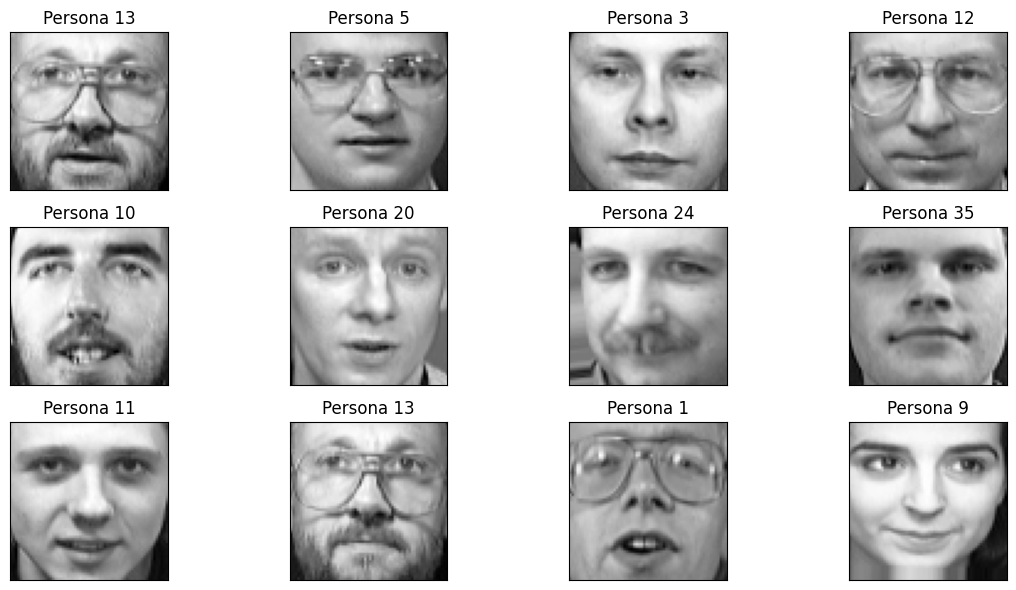

In [4]:
plt.figure(figsize=(12, 6))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Persona {y_train[i]}")
    plt.xticks([])
    plt.yticks([])

plt.tight_layout()
plt.show()


---
# 2. Construir la red neuronal

Usaremos una arquitectura fully-connected similar a la vista en clase:

```text
Imagen 64×64
     ↓
Flatten
     ↓
4096 valores
     ↓
Dense(64)
     ↓
ReLU
     ↓
Dense(40)
     ↓
Logits
```

La última capa debe tener una salida por cada clase.

> **Importante:** no añadas `Softmax` al final. Trabajaremos directamente con **logits**.


In [17]:
# TODO 1 — Completar la arquitectura.

model = keras.Sequential([
    #definimos el tamaño de las imagenes a usar
    keras.Input(shape=(64, 64)),
    #aplanamos las capas
    layers.Flatten(),
    #definimos los nodos de salida y el algoritmo de salida
    layers.Dense(
        64,
        activation="relu"
    ),
    #definimos el numero de categorias en las que lo vamos a clasificar
    layers.Dense(40)
])

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 40)             │         2,600 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 264,808 (1.01 MB)

 Trainable params: 264,808 (1.01 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
# Validación TODO 1

assert isinstance(model, keras.Model)

# Dense(64): 4096*64 + 64
# Dense(40): 64*40 + 40
expected_params = (4096 * 64 + 64) + (64 * 40 + 40)

assert model.count_params() == expected_params, (
    f"Se esperaban {expected_params:,} parámetros, "
    f"pero el modelo tiene {model.count_params():,}."
)

print("✓ Arquitectura correcta.")
print(f"Parámetros entrenables: {model.count_params():,}")


✓ Arquitectura correcta.
Parámetros entrenables: 264,808


### Pregunta 2

¿Por qué necesitamos `Flatten()` antes de la primera capa `Dense`?

**Respuesta:** Porque una capa Dense requiere una entrada unidimensional (un vector de características de 4096 elementos). Flatten() transforma la matriz 2D de la imagen en un vector 1D continuo



### Pregunta 3

¿Por qué la última capa tiene **40 neuronas**?

**Respuesta:** Porque el problema clasifica entre 40 identidades distintas (personas del 0 al 39). Cada neurona de salida calcula el puntaje no normalizado que corresponde a cada una de las clases

### Pregunta 4

¿Qué función cumple `ReLU` en la capa oculta?

**Respuesta:** limitar la vision de el modelo, lo que permite que este pueda obtener informacion relevante para identificar patrones o relciones complejas en la imagen




---
# 3. Configurar el entrenamiento

Las etiquetas son números enteros entre:

```text
0 y 39
```

Por eso usaremos:

```python
SparseCategoricalCrossentropy
```

Además:

- el modelo produce **logits**,
- usaremos **Adam**,
- mediremos **accuracy**.

Completa `model.compile()`.


In [19]:
lr_rate = 0.001

# TODO 2 — Configurar loss, optimizer y métrica.

model.compile(
  #inidicamos el modelo a utilizar
    optimizer=keras.optimizers.Adam(
        learning_rate=lr_rate
    ),
    # le indicamos como delimitar y penalizar las perdidas
    loss=keras.losses.SparseCategoricalCrossentropy(
        from_logits=True
    ),
    #le indicamos como medir la tasa de victorias
    metrics=["accuracy"]
)

print("✓ Modelo configurado.")


✓ Modelo configurado.


### Pregunta 5

¿Por qué usamos:

```python
from_logits=True
```

en la función de pérdida?

**Respuesta:** porque el modelo produce valores no normalizados, por esto se utiliza; para inidicarle al modelo que debe calcular el porcentaje de perdida directamente con los datos producidos, no usar estos datos como la probabilidad de la informacion producida




---
# 4. Entrenar el modelo

Usaremos:

```python
epochs = 30
batch_size = 32
```

El dataset es pequeño, por lo que el entrenamiento debería ser rápido.

Keras realizará internamente:

```text
Forward pass
      ↓
Calcular loss
      ↓
Backpropagation
      ↓
Actualizar parámetros con Adam
```

Completa la llamada a `fit()`.


In [20]:
epochs = 30
batch_size = 32

# TODO 3 — Entrenar el modelo.

history = model.fit(


  #definimos el set de datos y etiquetas a usar (X y Y)
    X_train,
    y_train,
  #pasamos los valores asignados de manera eterna
    epochs=epochs,
    batch_size=batch_size,
  # usamos un dataset de validacion
    validation_data=(X_test, y_test),

    shuffle=True
)


Epoch 1/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.0219 - loss: 3.9439 - val_accuracy: 0.0500 - val_loss: 3.6875
Epoch 2/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.0250 - loss: 3.6851 - val_accuracy: 0.0375 - val_loss: 3.6870
Epoch 3/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.0344 - loss: 3.6792 - val_accuracy: 0.0250 - val_loss: 3.6782
Epoch 4/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.0250 - loss: 3.6734 - val_accuracy: 0.0375 - val_loss: 3.6802
Epoch 5/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.0312 - loss: 3.6694 - val_accuracy: 0.0250 - val_loss: 3.6733
Epoch 6/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.0281 - loss: 3.6610 - val_accuracy: 0.0250 - val_loss: 3.6702
Epoch 7/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.0281 - loss: 3.6568 - val_accuracy: 0.0250 - val_loss: 3.6672
Epoch 8/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.0250 - loss: 3.6511 - val_accuracy: 0.0375 - v

### Pregunta 6

¿Qué representa una **epoch**?

**Respuesta:** un recorrido de el data set completo


### Pregunta 7

¿Qué significa `batch_size=32`?

**Respuesta:** el numero de subsets que se recorren previo a actualizar la sensibilidad de el modelo




---
## 4.1 Visualizar el entrenamiento

Esta parte está resuelta.

El dataset tiene muy pocos ejemplos comparado con el número de parámetros de la red.

Observa cuidadosamente la diferencia entre entrenamiento y validación.


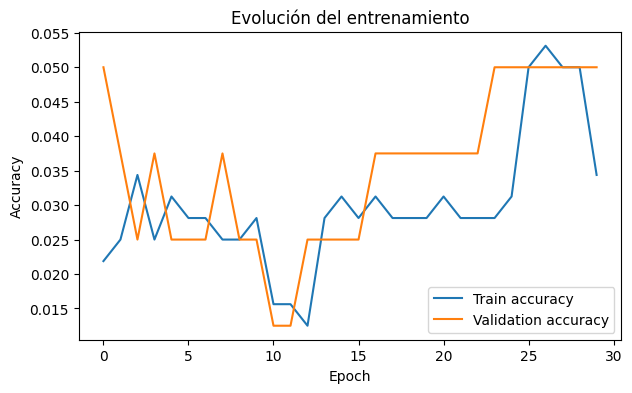

In [21]:
plt.figure(figsize=(7, 4))

plt.plot(
    history.history["accuracy"],
    label="Train accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Evolución del entrenamiento")
plt.legend()

plt.show()


### Pregunta 8

Observando la gráfica:

- ¿El accuracy de entrenamiento sigue aumentando?
- ¿El accuracy de validación se comporta igual?
- ¿Observas evidencia de **overfitting**?

**Respuesta:**
- no muestra una mejora consistente, hay casos en los que es mas preciso el el entrenamientos respecto a la validacion, y al mismo tiempo, es al reves en otros casos; no es claro si esta aumentando o solo se hizo el corte en un espacio muy conveniente para la grafica
-si
- no, al contrario, el modelo no esta aprendiendo patrones




---
# 5. Evaluar el modelo

Ahora evaluaremos el modelo sobre imágenes que no fueron utilizadas para actualizar sus parámetros.

Completa `evaluate()`.


In [22]:
# TODO 4 — Evaluar.

test_loss, test_accuracy = model.evaluate(

    X_test,
    y_test,

    batch_size=batch_size,
    verbose=0
)

print(f"Test loss     : {test_loss:.4f}")
print(f"Test accuracy : {test_accuracy:.4f}")
print(f"Accuracy (%)  : {test_accuracy * 100:.2f}%")


Test loss     : 3.5650
Test accuracy : 0.0500
Accuracy (%)  : 5.00%


### Pregunta 9

Tenemos **40 clases**, pero solamente **320 imágenes de entrenamiento**.

¿Crees que la cantidad de datos es grande o pequeña para una red con cientos de miles de parámetros?

**Respuesta:** es pequeña, dado la cantidad de informacion necesaria para identificar de manera correcta un rostro, el modelo actualmente esta "acomulando ruido", de lo que se puede utilizar; aun no tiene un referente claro



---
# 6. Logits y Softmax

La salida de nuestro modelo tiene forma:

```text
(batch_size, 40)
```

Cada uno de los 40 valores corresponde al **logit** asociado a una persona.

Los logits no son probabilidades.

Para convertirlos en probabilidades usamos:

```python
keras.ops.softmax(...)
```


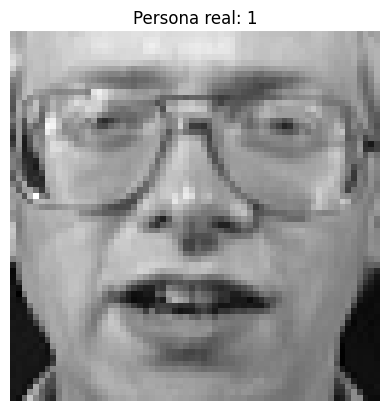

Shape de logits: (1, 40)

Primeros 10 logits:
[-0.00515691 -0.02446936 -0.01828484  0.01052571  0.00116716  0.02805432
  0.00119025 -0.05140797 -0.01931992 -0.0100453 ]


In [23]:
index = 0

image = X_test[index]
true_class = y_test[index]

plt.imshow(image, cmap="gray")
plt.title(f"Persona real: {true_class}")
plt.axis("off")
plt.show()

# Añadimos dimensión de batch:
# (64,64) -> (1,64,64)
image_batch = np.expand_dims(image, axis=0)

# Forward pass.
logits = model(
    image_batch,
    training=False
)

print("Shape de logits:", logits.shape)
print("\nPrimeros 10 logits:")
print(
    keras.ops.convert_to_numpy(logits)[0, :10]
)


In [25]:
# TODO 5 — Convertir logits a probabilidades.

probabilities = keras.ops.softmax(logits)

# TODO 6 — Obtener la clase con mayor probabilidad.

prediction = keras.ops.argmax(
    probabilities,
    axis=1
)

prediction = int(
    keras.ops.convert_to_numpy(prediction)[0]
)

print()
print("Persona real     :", true_class)
print("Persona predicha :", prediction)



Persona real     : 1
Persona predicha : 5


In [26]:
# Revisamos las cinco clases con mayor probabilidad.

probabilities_np = keras.ops.convert_to_numpy(
    probabilities
)[0]

top5 = np.argsort(
    probabilities_np
)[-5:][::-1]

print("Top 5 predicciones:\n")

for class_id in top5:
    print(
        f"Persona {class_id:2d}: "
        f"{probabilities_np[class_id]:.4f}"
    )

print(
    "\nSuma de probabilidades:",
    probabilities_np.sum()
)


Top 5 predicciones:

Persona  5: 0.0259
Persona 17: 0.0259
Persona 39: 0.0257
Persona 38: 0.0257
Persona 26: 0.0256

Suma de probabilidades: 1.0


### Pregunta 10

¿Por qué la suma de las 40 probabilidades obtenidas con `Softmax` debe ser aproximadamente `1`?

**Respuesta:** porque softmax calcula un porcentaje para cada categoria en la que puede pertenecer, debido a esto, al sumar las probabilidades, el resultado es 1.




---
# 7. Visualizar varias predicciones

Esta parte está resuelta.

Observa especialmente los casos en los que el modelo se equivoca.


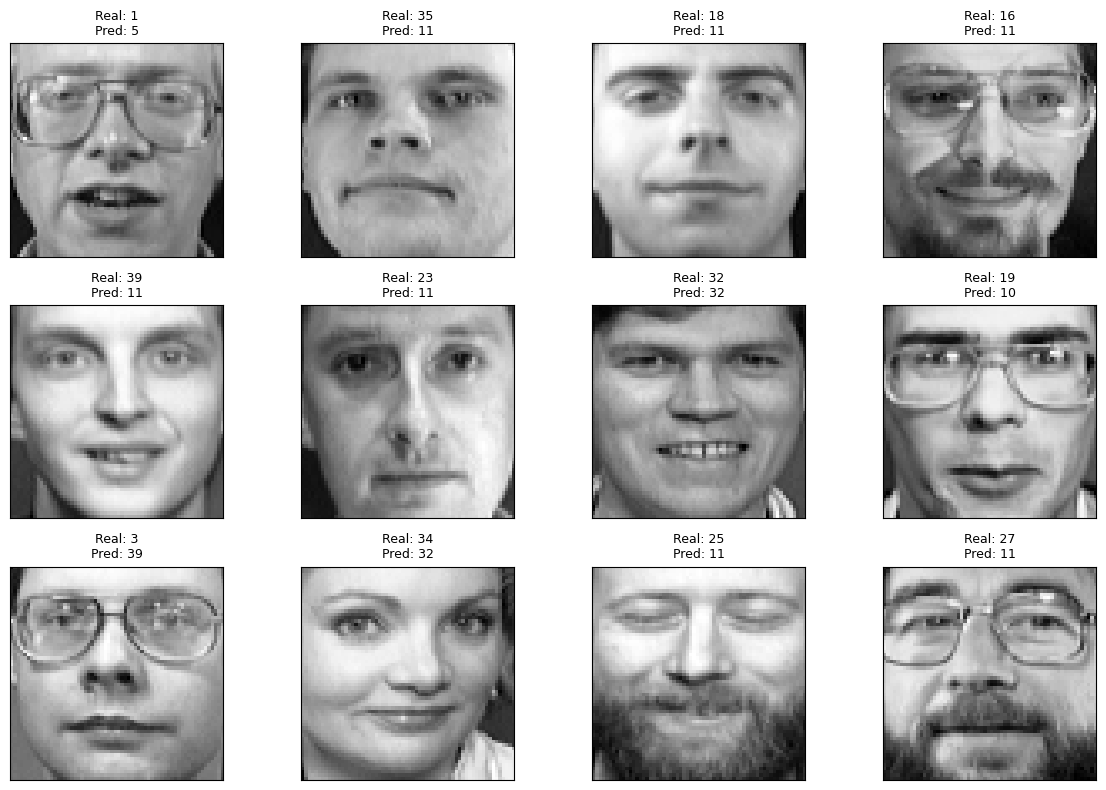

In [27]:
n = 12

logits_batch = model(
    X_test[:n],
    training=False
)

predictions = keras.ops.argmax(
    logits_batch,
    axis=1
)

predictions = keras.ops.convert_to_numpy(
    predictions
)

plt.figure(figsize=(12, 8))

for i in range(n):

    plt.subplot(3, 4, i + 1)

    plt.imshow(
        X_test[i],
        cmap="gray"
    )

    real = y_test[i]
    pred = predictions[i]

    plt.title(
        f"Real: {real}\nPred: {pred}",
        fontsize=9
    )

    plt.xticks([])
    plt.yticks([])

plt.tight_layout()
plt.show()


---
# 8. Reflexión final

Responde brevemente.

### 1. ¿Cuál fue el accuracy final del modelo?

**Respuesta:** 00.5%


### 2. ¿Observaste overfitting? ¿Qué evidencia utilizaste?

**Respuesta:** Según la gráfica obtenida, no se evidenció el sobreajuste típico (donde el entrenamiento alcanza valores muy altos y la validación cae). Más bien se observó un problema severo de subajuste (underfitting) e inestabilidad, con la precisión oscilando cerca del nivel del azar ($2.5\%$, que corresponde a $1/40$) sin lograr converger. (Nota: si en tu última ejecución el entrenamiento sí subió a valores altos mientras validación se quedó abajo, la evidencia sería la amplia brecha entre la curva de Train y la de Validation).   


### 3. ¿Qué ocurre cuando tenemos muchos parámetros pero pocos ejemplos de entrenamiento?


**Respuesta:** El modelo cuenta con demasiados grados de libertad en comparación con la evidencia disponible. Esto facilita que la red memorice el ruido y las particularidades de las pocas imágenes vistas en vez de extraer patrones visuales generalizables, provocando sobreajuste severo o impidiendo que el algoritmo de optimización encuentre una solución representativa.


### 4. Después de `Flatten()`, una cara de 64×64 se convierte en un vector de 4096 números; ¿Qué información sobre la estructura de la imagen deja de representar explícitamente esta transformación?

**Respuesta:** se pierde la ubicacion espacial de el pixel, lo que permitiria identificar patrones mas complejos e informacion relacionada con la ubicacion de el mismo, como por ejemplo


### 5. ¿Crees que una arquitectura diseñada específicamente para imágenes podría aprovechar mejor la información espacial?

**Respuesta:** sí, totalmente. Las Redes Neuronales Convolucionales (CNNs) preservan la matriz 2D y utilizan filtros locales que barren la imagen para capturar correlaciones espaciales, jerarquías visuales (bordes $\to$ texturas $\to$ partes del rostro) e invarianza a traslaciones espaciales, requiriendo además muchos menos parámetros que una red densa.


---

## Para pensar

Nuestra red recibe:

```text
64 × 64
   ↓
Flatten
   ↓
4096 números
   ↓
Dense
```

Pero una imagen tiene una estructura espacial:

- píxeles cercanos están relacionados,
- existen bordes,
- existen formas,
- existen patrones locales.

Una red fully-connected no incorpora explícitamente esa estructura.

Esto motiva una arquitectura diseñada específicamente para imágenes:

> **Convolutional Neural Networks (CNNs)**


---
# Resumen

En este ejercicio aplicaste nuevamente la receta básica de entrenamiento de una red neuronal:

```text
Dataset
   ↓
Train / Test split
   ↓
Sequential
   ↓
Flatten
   ↓
Dense + ReLU
   ↓
Dense(40)
   ↓
Cross-Entropy
   ↓
Adam
   ↓
fit()
   ↓
evaluate()
```

Los componentes de Keras son los mismos que usamos en clase.

Lo que cambió fue:

- el dataset,
- el tamaño de las imágenes,
- el número de clases,
- y la dificultad del problema.
